In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models  #type:ignore
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error

In [2]:
cols = ['unit', 'cycle', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)]

def load_data(path):
    return pd.read_csv(path, sep=' +', header=None,
                       usecols=range(26), names=cols, engine='python')

train = load_data('../Dataset/train_FD004.txt')
test  = load_data('../Dataset/test_FD004.txt')
rul   = pd.read_csv('../Dataset/RUL_FD004.txt', header=None, names=['rul'])

In [3]:
train.head()

,unit,cycle,os1,os2,os3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 61249 entries, 0 to 61248
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   unit    61249 non-null  int64  
 1   cycle   61249 non-null  int64  
 2   os1     61249 non-null  float64
 3   os2     61249 non-null  float64
 4   os3     61249 non-null  float64
 5   s1      61249 non-null  float64
 6   s2      61249 non-null  float64
 7   s3      61249 non-null  float64
 8   s4      61249 non-null  float64
 9   s5      61249 non-null  float64
 10  s6      61249 non-null  float64
 11  s7      61249 non-null  float64
 12  s8      61249 non-null  float64
 13  s9      61249 non-null  float64
 14  s10     61249 non-null  float64
 15  s11     61249 non-null  float64
 16  s12     61249 non-null  float64
 17  s13     61249 non-null  float64
 18  s14     61249 non-null  float64
 19  s15     61249 non-null  float64
 20  s16     61249 non-null  float64
 21  s17     61249 non-null  int64  
 22  s18     6

In [5]:
DROP_SENSORS  = ['s1','s5','s6','s8','s10','s13','s15','s16','s18','s19']
# Keep os3 for FD004 (it has 2 values, not 1)
KEEP_SENSORS  = ['s2','s3','s4','s7','s9','s11','s12','s14','s17','s20','s21']

train.drop(columns=DROP_SENSORS, inplace=True)
test.drop(columns=DROP_SENSORS, inplace=True)

In [6]:
def add_rul(df):
    max_cycle = df.groupby('unit')['cycle'].transform('max')
    df['RUL'] = max_cycle - df['cycle']
    return df

train = add_rul(train)

In [7]:
last_cycles = test.groupby('unit')['cycle'].max().reset_index()
last_cycles['RUL'] = rul['rul'].values
test = test.merge(last_cycles[['unit','RUL']], on='unit', how='left')
test_last = test.groupby('unit').last().reset_index()

In [8]:
#Rul clipping to handle outliers and focus on near-term predictions
RUL_CLIP = 140   # FD004 engines live up to 543 cycles — 125 loses the degradation window

train['RUL'] = train['RUL'].clip(upper=RUL_CLIP)

In [9]:
# String rounding creates 100s of unique "conditions" so test conditions
# never match train scalers → the core bug causing test RMSE = 33
SETTING_COLS = ['os1', 'os2', 'os3']

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
train['condition'] = kmeans.fit_predict(train[SETTING_COLS])
test['condition']  = kmeans.predict(test[SETTING_COLS])

print("Train condition distribution:\n", train['condition'].value_counts())
print("Test  condition distribution:\n", test['condition'].value_counts())

Train condition distribution:
 condition
0    15395
4     9238
1     9224
5     9162
2     9139
3     9091
Name: count, dtype: int64
Test  condition distribution:
 condition
0    10382
3     6254
5     6232
1     6185
2     6107
4     6054
Name: count, dtype: int64


In [10]:
# Cast KEEP_SENSORS to float64 BEFORE the scaling loop
train[KEEP_SENSORS] = train[KEEP_SENSORS].astype(np.float64)
test[KEEP_SENSORS]  = test[KEEP_SENSORS].astype(np.float64)

# Now the scaling loop will work fine
scalers = {}
for cond in range(6):
    scaler = MinMaxScaler()
    mask_tr = train['condition'] == cond
    mask_te = test['condition']  == cond
    train.loc[mask_tr, KEEP_SENSORS] = scaler.fit_transform(train.loc[mask_tr, KEEP_SENSORS])
    if mask_te.sum() > 0:
        test.loc[mask_te, KEEP_SENSORS] = scaler.transform(test.loc[mask_te, KEEP_SENSORS])
    scalers[cond] = scaler

In [11]:
WINDOW   = 30
FEATURES = KEEP_SENSORS

def build_sequences(df, feature_cols, window=WINDOW):
    X, y = [], []
    for _, engine_df in df.groupby('unit'):
        engine_df = engine_df.sort_values('cycle')
        data   = engine_df[feature_cols].values
        labels = engine_df['RUL'].values
        for i in range(len(data) - window + 1):
            X.append(data[i:i+window])
            y.append(labels[i+window-1])
    return np.array(X), np.array(y)

def build_last_sequences(df, feature_cols, window=WINDOW):
    X, y = [], []
    for _, engine_df in df.groupby('unit'):
        engine_df = engine_df.sort_values('cycle')
        data  = engine_df[feature_cols].values
        label = engine_df['RUL'].iloc[-1]
        if len(data) >= window:
            X.append(data[-window:])
        else:
            pad = np.zeros((window - len(data), len(feature_cols)))
            X.append(np.vstack([pad, data]))
        y.append(label)
    return np.array(X), np.array(y)

In [12]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(train, groups=train['unit']))

df_train = train.iloc[train_idx]
df_val   = train.iloc[val_idx]

In [13]:
X_train, y_train = build_sequences(df_train, FEATURES, WINDOW)
X_val,   y_val   = build_sequences(df_val,   FEATURES, WINDOW)
X_test,  y_test  = build_last_sequences(test, FEATURES, WINDOW)

# Normalize targets to [0,1] for training stability
X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)
X_test  = X_test.astype(np.float32)

y_train_n = (y_train / RUL_CLIP).astype(np.float32)
y_val_n   = (y_val   / RUL_CLIP).astype(np.float32)

In [14]:
def build_gru(window, n_features):
    inp = tf.keras.Input(shape=(window, n_features))
    x = layers.GRU(128, return_sequences=True)(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.GRU(64, return_sequences=True)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.GRU(32)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dense(16, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)  # sigmoid keeps output in [0,1]
    return models.Model(inp, out)

In [15]:
model = build_gru(WINDOW, len(FEATURES))
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='mse',
    metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 11)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 30, 128)        │        54,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 30, 64)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,401 (400.00 KB)

 Trainable params: 102,401 (400.00 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-5, verbose=1
    )
]

In [17]:
history = model.fit(
    X_train, y_train_n,
    validation_data=(X_val, y_val_n),
    epochs=50,          
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 23s 111ms/step - loss: 0.0655 - rmse: 0.2559 - val_loss: 0.0352 - val_rmse: 0.1877 - learning_rate: 3.0000e-04
Epoch 2/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 20s 115ms/step - loss: 0.0294 - rmse: 0.1713 - val_loss: 0.0337 - val_rmse: 0.1836 - learning_rate: 3.0000e-04
Epoch 3/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - loss: 0.0268 - rmse: 0.1636 - val_loss: 0.0292 - val_rmse: 0.1709 - learning_rate: 3.0000e-04
Epoch 4/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step - loss: 0.0238 - rmse: 0.1543 - val_loss: 0.0277 - val_rmse: 0.1665 - learning_rate: 3.0000e-04
Epoch 5/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - loss: 0.0223 - rmse: 0.1492 - val_loss: 0.0311 - val_rmse: 0.1763 - learning_rate: 3.0000e-04
Epoch 6/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - loss: 0.0227 - rmse: 0.1505 - val_loss: 0.0325 - val_rmse: 0.1804 - learning_rate: 3.0000e-04
Epoch 7/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step - loss: 0.0208 - rmse: 0.1444 - val_los

In [18]:
val_preds  = model.predict(X_val)  * RUL_CLIP
test_preds = model.predict(X_test) * RUL_CLIP

y_val_true  = y_val
y_test_true = y_test

rmse_val  = np.sqrt(mean_squared_error(y_val_true,  val_preds))
rmse_test = np.sqrt(mean_squared_error(y_test_true, test_preds))

print(f"Val RMSE:  {rmse_val:.2f}")
print(f"Test RMSE: {rmse_test:.2f}")

# NASA asymmetric score (penalizes late predictions more)
def nasa_score(y_true, y_pred):
    d = y_pred.flatten() - y_true.flatten()
    scores = np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)
    return float(np.sum(scores))

print(f"NASA Score: {nasa_score(y_test_true, test_preds):.1f}")

329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Val RMSE:  21.38
Test RMSE: 36.09
NASA Score: 1048288.6


In [19]:
results = pd.DataFrame({
    'unit': test_last['unit'].values,
    'true_RUL': test_last['RUL'].values,
    'pred_RUL': test_preds.flatten()
})
results.head(10)


,unit,true_RUL,pred_RUL
0,1,22,38.737041
1,2,39,60.353279
2,3,107,130.101578
3,4,75,108.670822
4,5,149,110.241211
5,6,78,105.069511
6,7,94,108.421967
7,8,14,22.470646
8,9,99,129.695587
9,10,162,14.654226


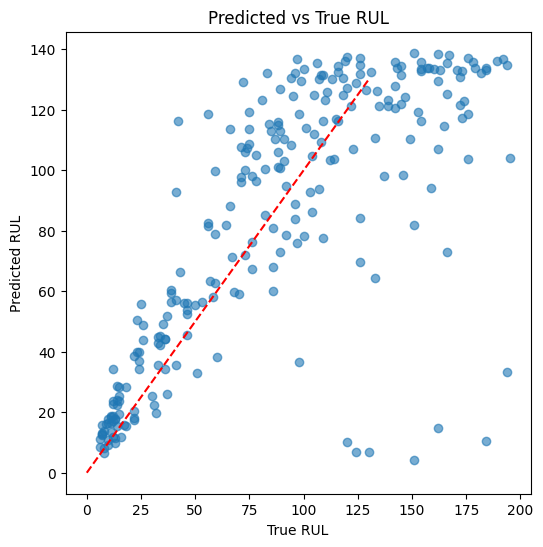

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(results['true_RUL'], results['pred_RUL'], alpha=0.6)
plt.plot([0, 130], [0, 130], 'r--')  # ideal line
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs True RUL")
plt.show()

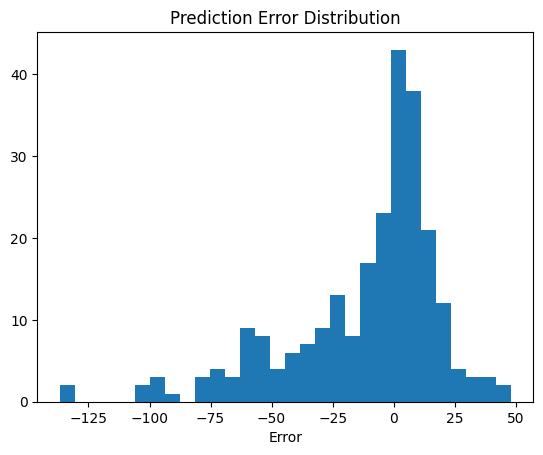

In [26]:
results['error'] = results['pred_RUL'] - results['true_RUL']

plt.hist(results['error'], bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.show()

In [27]:
results['abs_error'] = results['error'].abs()

worst = results.sort_values(by='abs_error', ascending=False).head(10)
worst

,unit,true_RUL,pred_RUL,error,abs_error
124,125,184,47.281876,-136.718124,136.718124
203,204,151,14.931618,-136.068382,136.068382
9,10,162,57.056637,-104.943363,104.943363
126,127,195,91.754272,-103.245728,103.245728
18,19,194,94.483574,-99.516426,99.516426
140,141,130,32.775372,-97.224628,97.224628
238,239,166,72.043381,-93.956619,93.956619
27,28,124,31.121248,-92.878752,92.878752
228,229,120,41.268745,-78.731255,78.731255
38,39,151,74.331970,-76.668030,76.668030


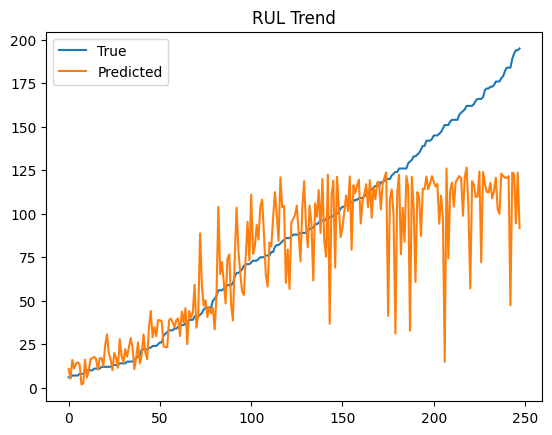

In [28]:
results_sorted = results.sort_values(by='true_RUL')

plt.plot(results_sorted['true_RUL'].values, label='True')
plt.plot(results_sorted['pred_RUL'].values, label='Predicted')
plt.legend()
plt.title("RUL Trend")
plt.show()

In [29]:
results['critical_true'] = results['true_RUL'] < 30
results['critical_pred'] = results['pred_RUL'] < 30

from sklearn.metrics import confusion_matrix

confusion_matrix(results['critical_true'], results['critical_pred'])

array([[190,   6],
       [  8,  44]])